# fitstat0_2727 Relaxed Eval Compare

这个 notebook 用来分析 `fitstat0_2727` 模型在“只在评估阶段放宽 cuts”时的泛化表现。

比较的三组评估实验是：

1. `dcedge`: baseline `dcedge_min=20` vs relaxed `dcedge_min=0`
2. `dangle`: baseline `dangle_max_deg=3` vs relaxed `dangle_max_deg=999`
3. `pincness`: baseline `pinc_max=1.1` vs relaxed `pinc_max=9999`

每组都会基于 `preds.npz` 和 `metrics.json` 重算并绘制三张 `mc-weighted` 对比图：

- `resolution_weighted`
- `bias_weighted`
- `logRMS_weighted`


## 1. 设置路径并准备加权统计函数

这一格只做环境准备：定义项目路径、输出路径，并内联当前项目里使用的加权统计公式。

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/server/projects/energy_reconstruction')
RUN_DIR = PROJECT_ROOT / 'runs' / 'fitstat0_2727'
OUTPUT_DIR = PROJECT_ROOT / 'notebook' / 'generated' / 'fitstat0_2727_relaxed_eval_compare'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def _weighted_mean(x, w):
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    return np.sum(w * x) / s

def _weighted_var(x, w):
    m = _weighted_mean(x, w)
    if not np.isfinite(m):
        return np.nan
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    return np.sum(w * (x - m) ** 2) / s

def _weighted_std(x, w):
    v = _weighted_var(x, w)
    return np.sqrt(v) if np.isfinite(v) and v >= 0 else np.nan

def _weighted_rms(x, w):
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    return np.sqrt(np.sum(w * x ** 2) / s)

print('RUN_DIR    =', RUN_DIR)
print('OUTPUT_DIR =', OUTPUT_DIR)


RUN_DIR    = /home/server/projects/energy_reconstruction/runs/fitstat0_2727
OUTPUT_DIR = /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare


## 2. 自动识别 6 个评估输出目录

这里不手工抄目录名对应的结果，而是统一按预期目录名检查并打印实际读取路径。

In [2]:
GROUPS = {
    'dcedge': {
        'baseline': 'fig_eval_dcedge20_baseline',
        'relaxed': 'fig_eval_dcedge0_relaxed',
        'baseline_label': 'Baseline: dcedge_min = 20',
        'relaxed_label': 'Relaxed: dcedge_min = 0',
    },
    'dangle': {
        'baseline': 'fig_eval_dangle3_baseline',
        'relaxed': 'fig_eval_dangle_relaxed',
        'baseline_label': 'Baseline: dangle_max_deg = 3',
        'relaxed_label': 'Relaxed: dangle_max_deg = 999',
    },
    'pincness': {
        'baseline': 'fig_eval_pinc1p1_baseline',
        'relaxed': 'fig_eval_pinc_relaxed',
        'baseline_label': 'Baseline: pinc_max = 1.1',
        'relaxed_label': 'Relaxed: pinc_max = 9999',
    },
}

RESULTS = {}
for group_name, item in GROUPS.items():
    RESULTS[group_name] = {}
    for mode in ['baseline', 'relaxed']:
        out_dir = RUN_DIR / item[mode]
        effective_config_path = out_dir / 'effective_eval_config.json'
        metrics_path = out_dir / 'metrics.json'
        preds_path = out_dir / 'preds.npz'

        assert out_dir.exists(), f'Missing evaluation dir: {out_dir}'
        assert effective_config_path.exists(), f'Missing effective config: {effective_config_path}'
        assert metrics_path.exists(), f'Missing metrics: {metrics_path}'
        assert preds_path.exists(), f'Missing preds: {preds_path}'

        RESULTS[group_name][mode] = {
            'out_dir': out_dir,
            'effective_config_path': effective_config_path,
            'metrics_path': metrics_path,
            'preds_path': preds_path,
            'display': item[f'{mode}_label'],
        }

for group_name, pair in RESULTS.items():
    print(group_name)
    for mode, item in pair.items():
        print(f'  {mode:8s} -> {item["out_dir"]}')
        print(f'    metrics : {item["metrics_path"]}')
        print(f'    preds   : {item["preds_path"]}')
        print(f'    config  : {item["effective_config_path"]}')


dcedge
  baseline -> /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge20_baseline
    metrics : /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge20_baseline/metrics.json
    preds   : /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge20_baseline/preds.npz
    config  : /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge20_baseline/effective_eval_config.json
  relaxed  -> /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge0_relaxed
    metrics : /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge0_relaxed/metrics.json
    preds   : /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge0_relaxed/preds.npz
    config  : /home/server/projects/energy_reconstruction/runs/fitstat0_2727/fig_eval_dcedge0_relaxed/effective_eval_config.json
dangle
  baseline -> /home/server/projects/energy_reconstruction/runs

## 3. 读取 `effective_eval_config.json`、`metrics.json` 和 `preds.npz`

每组 baseline / relaxed 都直接从结果文件读取，不手工输入任何数字。

In [3]:
loaded = {}
for group_name, pair in RESULTS.items():
    loaded[group_name] = {}
    for mode, item in pair.items():
        with open(item['effective_config_path'], 'r', encoding='utf-8') as f:
            effective_config = json.load(f)
        with open(item['metrics_path'], 'r', encoding='utf-8') as f:
            metrics = json.load(f)
        preds = np.load(item['preds_path'])

        loaded[group_name][mode] = {
            'display': item['display'],
            'effective_config': effective_config,
            'metrics': metrics,
            'logE_true': preds['logE_true'].astype(np.float64),
            'logE_pred': preds['logE_pred'].astype(np.float64),
            'mc_weight': preds['mc_weight'].astype(np.float64),
        }

for group_name, pair in loaded.items():
    print(group_name)
    for mode, item in pair.items():
        print({
            'mode': mode,
            'display': item['display'],
            'n': item['metrics'].get('n'),
            'w_log_sigma': item['metrics'].get('w_log_sigma'),
            'w_log_rmse': item['metrics'].get('w_log_rmse'),
            'w_log_bias': item['metrics'].get('w_log_bias'),
        })


dcedge
{'mode': 'baseline', 'display': 'Baseline: dcedge_min = 20', 'n': 423617, 'w_log_sigma': 0.207138605715529, 'w_log_rmse': 0.2087544483302951, 'w_log_bias': 0.02592330555273714}
{'mode': 'relaxed', 'display': 'Relaxed: dcedge_min = 0', 'n': 667023, 'w_log_sigma': 0.21231933612684242, 'w_log_rmse': 0.21232243922296268, 'w_log_bias': 0.001147924669430697}
dangle
{'mode': 'baseline', 'display': 'Baseline: dangle_max_deg = 3', 'n': 423617, 'w_log_sigma': 0.2071507376086264, 'w_log_rmse': 0.20876837821723718, 'w_log_bias': 0.02593853283901741}
{'mode': 'relaxed', 'display': 'Relaxed: dangle_max_deg = 999', 'n': 503431, 'w_log_sigma': 0.3286197777568746, 'w_log_rmse': 0.3325252738436309, 'w_log_bias': 0.05081434669454689}
pincness
{'mode': 'baseline', 'display': 'Baseline: pinc_max = 1.1', 'n': 423617, 'w_log_sigma': 0.20714984313540835, 'w_log_rmse': 0.208765499582046, 'w_log_bias': 0.02592250904469798}
{'mode': 'relaxed', 'display': 'Relaxed: pinc_max = 9999', 'n': 1156129, 'w_log_si

## 4. 打印每组 baseline 和 relaxed 的实际评估 cuts

这一格专门把 `effective_eval_config.json` 里的关键 cut 参数打印出来，便于确认每组对比到底改了什么。

In [4]:
for group_name, pair in loaded.items():
    print(f'[{group_name}]')
    for mode in ['baseline', 'relaxed']:
        cfg = pair[mode]['effective_config']
        print({
            'mode': mode,
            'display': pair[mode]['display'],
            'effective_eval_dcedge_min': cfg.get('effective_eval_dcedge_min'),
            'effective_eval_dangle_max_deg': cfg.get('effective_eval_dangle_max_deg'),
            'effective_eval_pinc_max': cfg.get('effective_eval_pinc_max'),
            'effective_eval_require_fitstat0': cfg.get('effective_eval_require_fitstat0'),
        })
    print()


[dcedge]
{'mode': 'baseline', 'display': 'Baseline: dcedge_min = 20', 'effective_eval_dcedge_min': 20.0, 'effective_eval_dangle_max_deg': 3.0, 'effective_eval_pinc_max': 1.1, 'effective_eval_require_fitstat0': True}
{'mode': 'relaxed', 'display': 'Relaxed: dcedge_min = 0', 'effective_eval_dcedge_min': 0.0, 'effective_eval_dangle_max_deg': 3.0, 'effective_eval_pinc_max': 1.1, 'effective_eval_require_fitstat0': True}

[dangle]
{'mode': 'baseline', 'display': 'Baseline: dangle_max_deg = 3', 'effective_eval_dcedge_min': 20.0, 'effective_eval_dangle_max_deg': 3.0, 'effective_eval_pinc_max': 1.1, 'effective_eval_require_fitstat0': True}
{'mode': 'relaxed', 'display': 'Relaxed: dangle_max_deg = 999', 'effective_eval_dcedge_min': 20.0, 'effective_eval_dangle_max_deg': 999.0, 'effective_eval_pinc_max': 1.1, 'effective_eval_require_fitstat0': True}

[pincness]
{'mode': 'baseline', 'display': 'Baseline: pinc_max = 1.1', 'effective_eval_dcedge_min': 20.0, 'effective_eval_dangle_max_deg': 3.0, 'eff

## 5. 用共享 true-energy bins 重算加权曲线

这里复用当前项目中的定义：

- `bias = weighted mean(logE_pred - logE_true)`
- `resolution = weighted std(logE_pred)`
- `logRMS = weighted rms(logE_pred - logE_true)`

每组内部使用共同的 true-energy bin，这样 baseline 和 relaxed 可以直接在同一张图上比较。

In [5]:
def compute_weighted_curves(log_true, log_pred, weights, bin_edges):
    mask = (
        np.isfinite(log_true)
        & np.isfinite(log_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    log_true = log_true[mask]
    log_pred = log_pred[mask]
    weights = weights[mask]

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bias = []
    resolution = []
    log_rms = []

    for i in range(len(bin_edges) - 1):
        m = (log_true >= bin_edges[i]) & (log_true < bin_edges[i + 1])
        if m.sum() > 10:
            residual = log_pred[m] - log_true[m]
            w = weights[m]
            bias.append(float(_weighted_mean(residual, w)))
            resolution.append(float(_weighted_std(log_pred[m], w)))
            log_rms.append(float(_weighted_rms(residual, w)))
        else:
            bias.append(np.nan)
            resolution.append(np.nan)
            log_rms.append(np.nan)

    return {
        'bin_centers': centers,
        'bias': np.asarray(bias, dtype=np.float64),
        'resolution': np.asarray(resolution, dtype=np.float64),
        'log_rms': np.asarray(log_rms, dtype=np.float64),
    }

curves = {}
for group_name, pair in loaded.items():
    all_true = np.concatenate([
        pair['baseline']['logE_true'][np.isfinite(pair['baseline']['logE_true'])],
        pair['relaxed']['logE_true'][np.isfinite(pair['relaxed']['logE_true'])],
    ])
    bin_edges = np.linspace(all_true.min(), all_true.max(), 21)
    curves[group_name] = {
        mode: compute_weighted_curves(
            pair[mode]['logE_true'],
            pair[mode]['logE_pred'],
            pair[mode]['mc_weight'],
            bin_edges,
        )
        for mode in ['baseline', 'relaxed']
    }
    print(group_name)
    for mode in ['baseline', 'relaxed']:
        valid_bins = np.isfinite(curves[group_name][mode]['bias']).sum()
        print(f'  {mode}: valid bins = {valid_bins}')


dcedge
  baseline: valid bins = 20
  relaxed: valid bins = 20
dangle
  baseline: valid bins = 20
  relaxed: valid bins = 20
pincness
  baseline: valid bins = 20
  relaxed: valid bins = 20


## 6. 定义统一绘图函数

下面的绘图函数会为每组生成 3 张图，并统一保存到 `notebook/generated/fitstat0_2727_relaxed_eval_compare/`。

In [6]:
MODE_STYLE = {
    'baseline': {'color': '#1f77b4', 'marker': 'o'},
    'relaxed': {'color': '#d62728', 'marker': 's'},
}

def plot_group_compare(group_name, metric_key, ylabel, title_suffix, filename_suffix, draw_zero=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for mode in ['baseline', 'relaxed']:
        item = loaded[group_name][mode]
        curve = curves[group_name][mode]
        style = MODE_STYLE[mode]
        ax.plot(
            curve['bin_centers'],
            curve[metric_key],
            marker=style['marker'],
            color=style['color'],
            linewidth=2,
            markersize=5,
            label=item['display'],
        )

    if draw_zero:
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel(r'True Energy $\log_{10}(E/\mathrm{GeV})$')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{group_name}: {title_suffix}')
    ax.legend(frameon=True, title='Eval mode')
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_path = OUTPUT_DIR / f'{group_name}_{filename_suffix}.png'
    fig.savefig(out_path, dpi=200)
    plt.show()
    print('saved:', out_path)
    return out_path


## 7. 生成 9 张对比图

下面按 `dcedge`、`dangle`、`pincness` 三组分别绘制：

- `resolution_weighted`
- `bias_weighted`
- `logRMS_weighted`


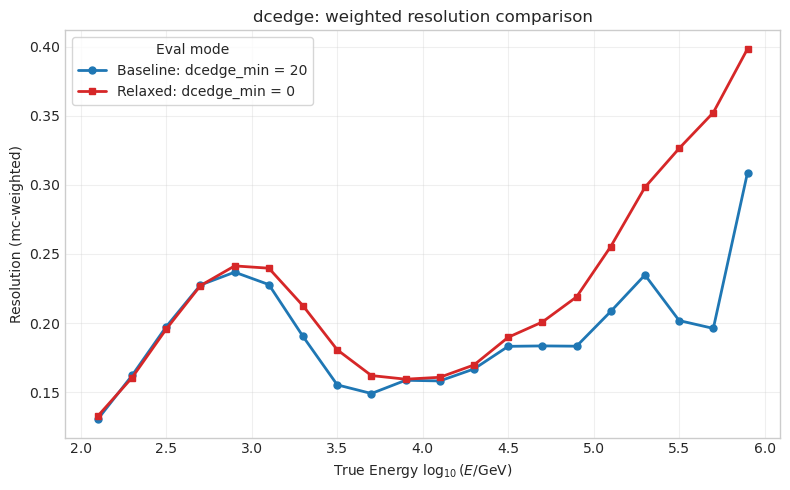

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dcedge_resolution_weighted_compare.png


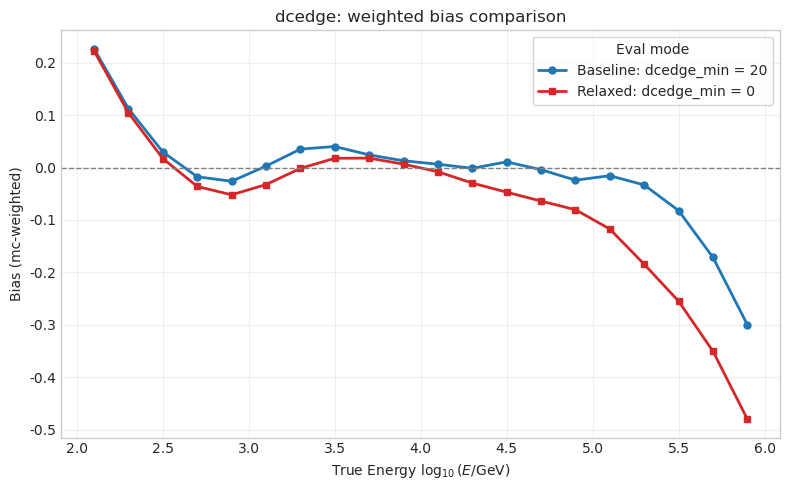

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dcedge_bias_weighted_compare.png


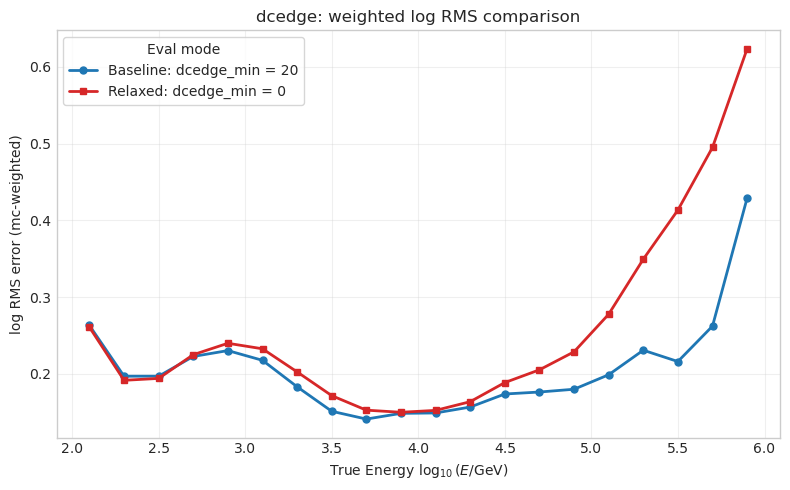

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dcedge_logRMS_weighted_compare.png


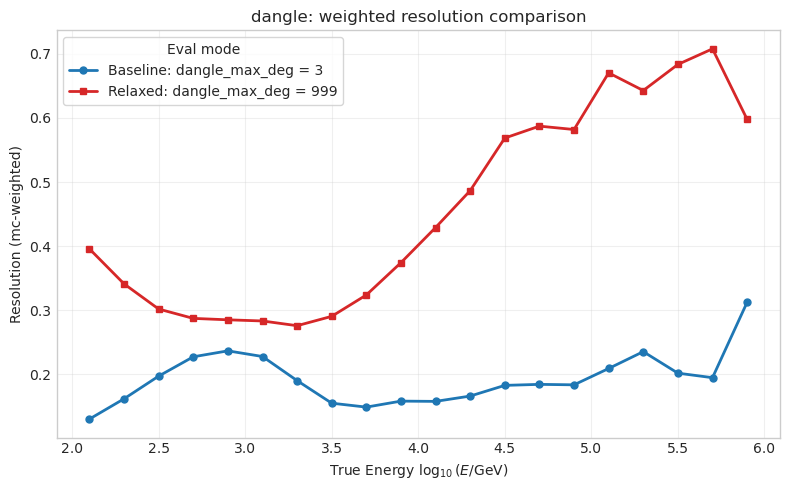

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dangle_resolution_weighted_compare.png


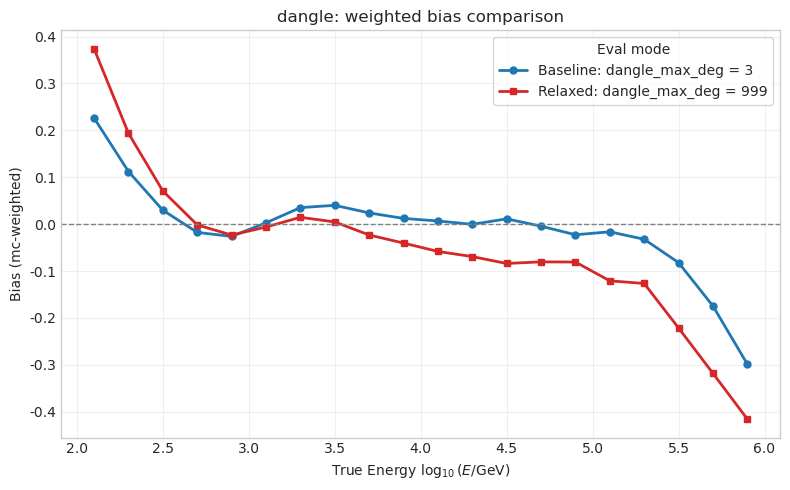

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dangle_bias_weighted_compare.png


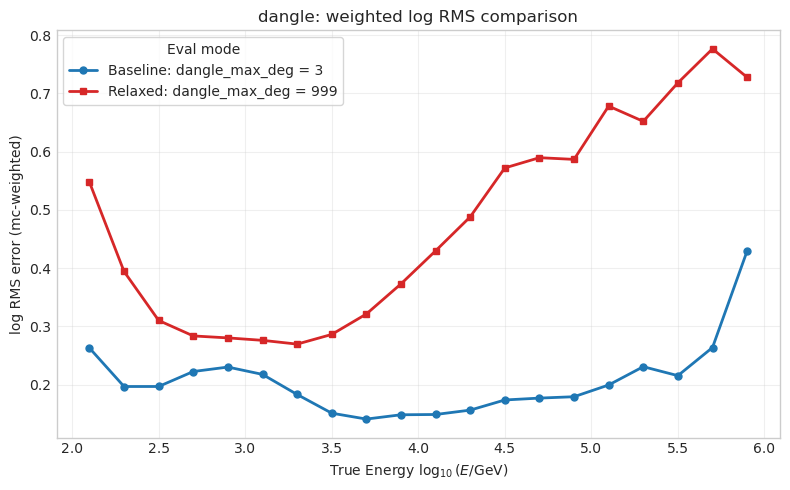

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dangle_logRMS_weighted_compare.png


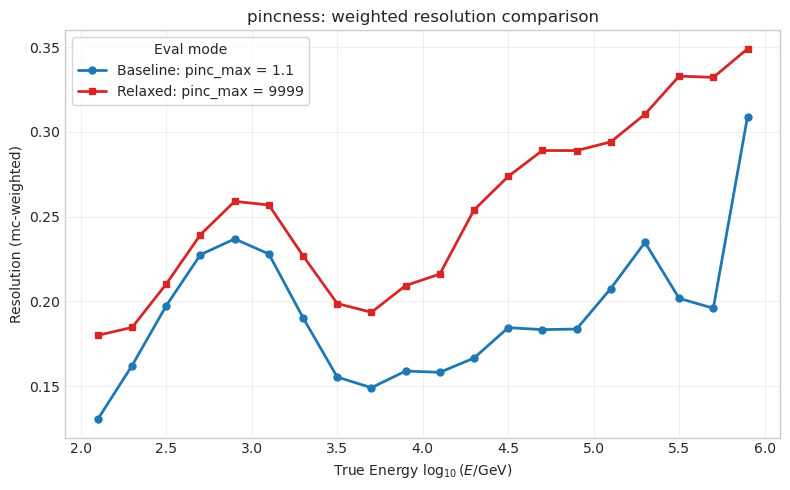

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/pincness_resolution_weighted_compare.png


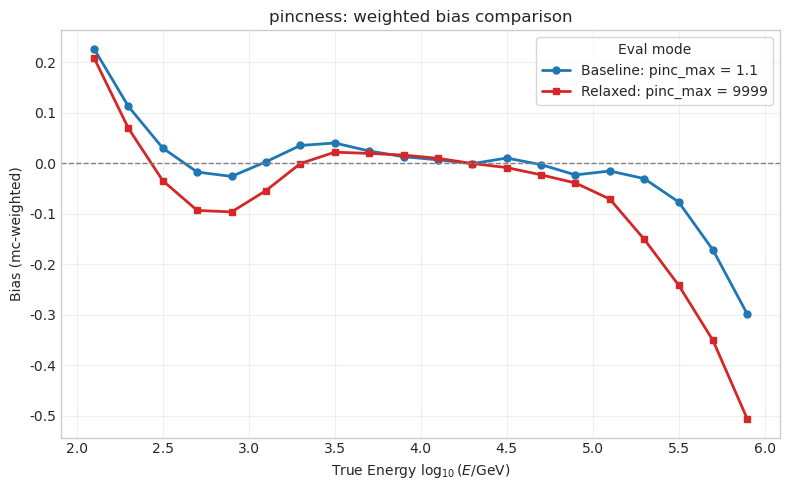

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/pincness_bias_weighted_compare.png


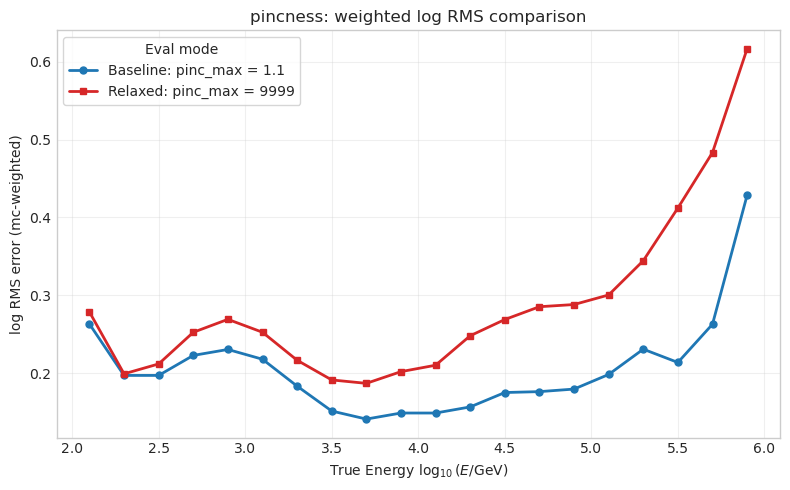

saved: /home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/pincness_logRMS_weighted_compare.png
Generated 9 figures.


In [7]:
generated_paths = []
for group_name in ['dcedge', 'dangle', 'pincness']:
    generated_paths.append(plot_group_compare(
        group_name=group_name,
        metric_key='resolution',
        ylabel='Resolution (mc-weighted)',
        title_suffix='weighted resolution comparison',
        filename_suffix='resolution_weighted_compare',
        draw_zero=False,
    ))
    generated_paths.append(plot_group_compare(
        group_name=group_name,
        metric_key='bias',
        ylabel='Bias (mc-weighted)',
        title_suffix='weighted bias comparison',
        filename_suffix='bias_weighted_compare',
        draw_zero=True,
    ))
    generated_paths.append(plot_group_compare(
        group_name=group_name,
        metric_key='log_rms',
        ylabel='log RMS error (mc-weighted)',
        title_suffix='weighted log RMS comparison',
        filename_suffix='logRMS_weighted_compare',
        draw_zero=False,
    ))

print(f'Generated {len(generated_paths)} figures.')


## 8. 汇总输出图路径

最后确认 notebook 生成的全部图像文件路径。

In [8]:
for path in generated_paths:
    print(path)


/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dcedge_resolution_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dcedge_bias_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dcedge_logRMS_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dangle_resolution_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dangle_bias_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/dangle_logRMS_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/fitstat0_2727_relaxed_eval_compare/pincness_resolution_weighted_compare.png
/home/server/projects/energy_reconstruction/notebook/genera